# Real Nuts ML Classifier: Wavelet + CNN Patch-Based Defect Detection

This notebook implements a defect detection classifier for factory-line hazelnut images using:
- **Wavelet transform** preprocessing (comparing single-channel cA vs multi-scale)
- **64x64 patch-based CNN** classifier
- **Leave-one-out cross-validation** to prevent data leakage

Based on the approach from `cnn_wavelet_hazelnut_1.ipynb` adapted for the `real_nuts_ml` dataset.

## 0. Setup and Configuration

In [38]:
from pathlib import Path
import random
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

try:
    import pywt
except ImportError as exc:
    raise ImportError("PyWavelets required. Install with `pip install PyWavelets`.") from exc

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
except ImportError as exc:
    raise ImportError("PyTorch required. Install with `pip install torch torchvision`.") from exc

# Reproducibility
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR = Path("data/real_nuts_ml")
REAL_NUTS_DIR = Path("data/real_nuts")

# Image and patch configuration
IMG_SIZE = 256
PATCH_SIZE = 64
WAVELET = "db2"
WAVELET_LEVEL = 2

# Training configuration
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR = 1e-3

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Validate paths
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

Using device: cpu


## 1. Load Labeled Data from Webapp

Using your `hazelnut_labels.csv` with 1382 labeled nut crops (997 bad, 386 good).

In [39]:
# Load labeled data from webapp
LABELS_CSV = Path("hazelnut_labels.csv")
STAGING_DIR = Path("data/labeling_staging/unlabeled")

labels_df = pd.read_csv(LABELS_CSV)
print(f"Loaded {len(labels_df)} labeled samples")
print(f"Label distribution:")
print(labels_df['bucket'].value_counts())

# Map webapp filenames to actual jpg paths
# CSV: IMG_1291_nut_65_1770185167866_1555.webp -> IMG_1291_nut_65.jpg
import re

def webp_to_jpg_path(webp_filename):
    """Convert webapp filename to staging folder jpg path."""
    # Extract base: IMG_XXXX_nut_YY from IMG_XXXX_nut_YY_timestamp_id.webp
    match = re.match(r'(IMG_\d+_nut_\d+)_\d+_\d+\.webp', webp_filename)
    if match:
        base = match.group(1)
        return STAGING_DIR / f"{base}.jpg"
    return None

# Add jpg paths and filter to existing files
labels_df['jpg_path'] = labels_df['filename'].apply(webp_to_jpg_path)
labels_df['exists'] = labels_df['jpg_path'].apply(lambda p: p.exists() if p else False)

print(f"\nFiles found: {labels_df['exists'].sum()} / {len(labels_df)}")

# Filter to existing files only
labeled_data = labels_df[labels_df['exists']].copy()
labeled_data['label'] = (labeled_data['bucket'] == 'bad').astype(int)  # 1=defect, 0=good
labeled_data['source_image'] = labeled_data['filename'].apply(lambda x: re.match(r'(IMG_\d+)', x).group(1))

print(f"\nUsable labeled samples: {len(labeled_data)}")
print(f"  Good: {(labeled_data['label'] == 0).sum()}")
print(f"  Defect: {(labeled_data['label'] == 1).sum()}")
print(f"  Source images: {labeled_data['source_image'].nunique()}")

labeled_data.head()

Loaded 1383 labeled samples
Label distribution:
bucket
bad     997
good    386
Name: count, dtype: int64

Files found: 1383 / 1383

Usable labeled samples: 1383
  Good: 386
  Defect: 997
  Source images: 9


,filename,bucket,cumulative_confidence,jpg_path,exists,label,source_image
0,IMG_1291_nut_65_1770185167866_1555.webp,good,70.0,data/labeling_staging/unlabeled/IMG_1291_nut_6...,True,0,IMG_1291
1,IMG_1291_nut_68_1770185167180_1553.webp,good,100.0,data/labeling_staging/unlabeled/IMG_1291_nut_6...,True,0,IMG_1291
2,IMG_1291_nut_72_1770185166468_1551.webp,good,100.0,data/labeling_staging/unlabeled/IMG_1291_nut_7...,True,0,IMG_1291
3,IMG_1291_nut_87_1770185116536_1418.webp,good,70.0,data/labeling_staging/unlabeled/IMG_1291_nut_8...,True,0,IMG_1291
4,IMG_1291_nut_88_1770185131872_1457.webp,good,60.0,data/labeling_staging/unlabeled/IMG_1291_nut_8...,True,0,IMG_1291


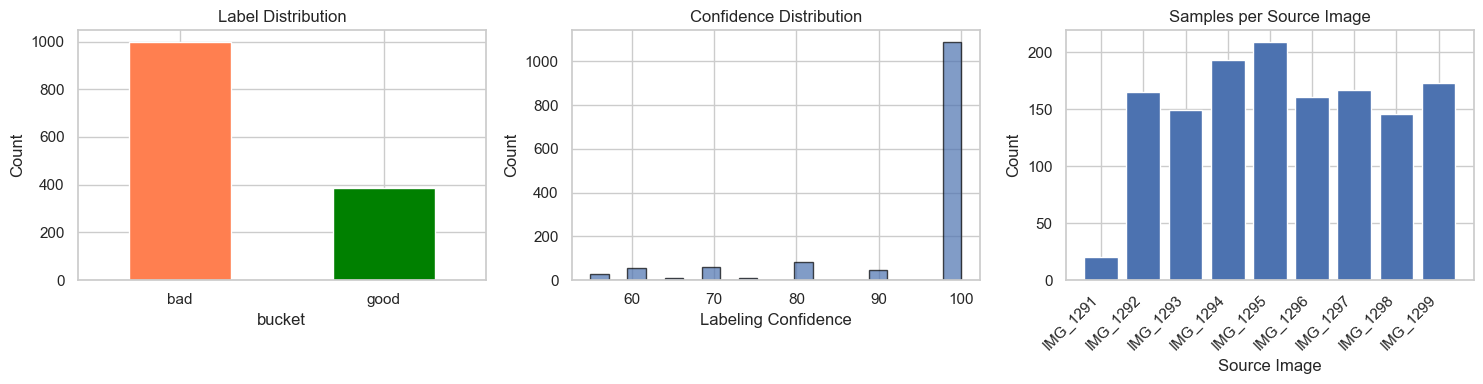


High confidence samples (>=70): 1288
  Good: 320
  Defect: 968


In [40]:
# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
labeled_data['bucket'].value_counts().plot(kind='bar', ax=axes[0], color=['coral', 'green'])
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Confidence distribution
axes[1].hist(labeled_data['cumulative_confidence'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Labeling Confidence")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence Distribution")

# Samples per source image
source_counts = labeled_data['source_image'].value_counts().sort_index()
axes[2].bar(range(len(source_counts)), source_counts.values)
axes[2].set_xlabel("Source Image")
axes[2].set_ylabel("Count")
axes[2].set_title("Samples per Source Image")
axes[2].set_xticks(range(len(source_counts)))
axes[2].set_xticklabels(source_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# High confidence samples
high_conf = labeled_data[labeled_data['cumulative_confidence'] >= 70]
print(f"\nHigh confidence samples (>=70): {len(high_conf)}")
print(f"  Good: {(high_conf['label'] == 0).sum()}")
print(f"  Defect: {(high_conf['label'] == 1).sum()}")

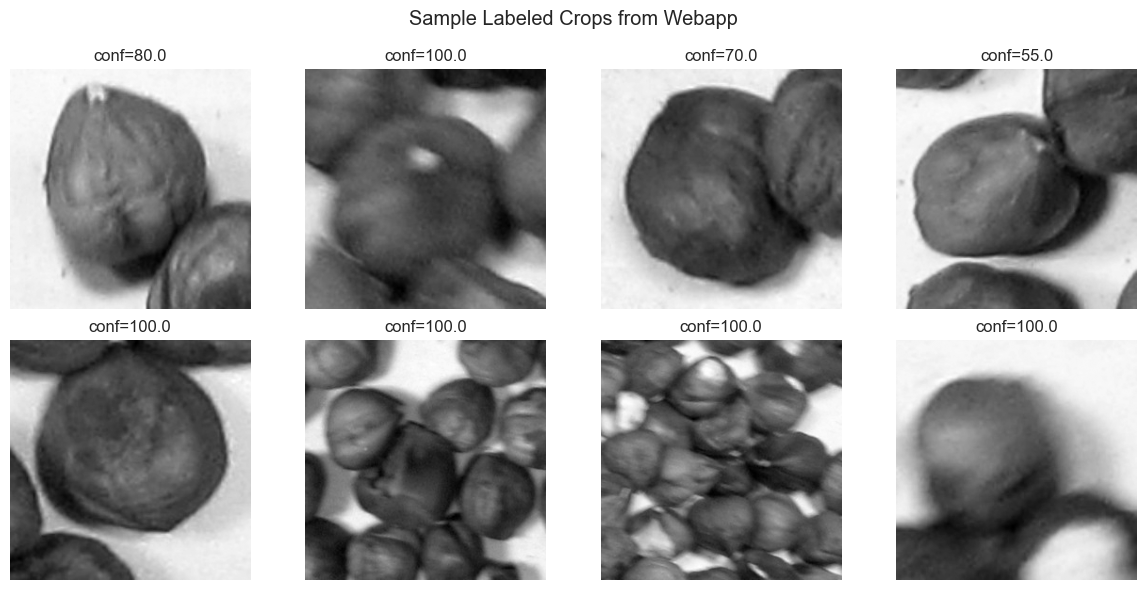

In [41]:
# Visualize sample labeled crops
n_samples = 4

# Sample good and defect
good_samples = labeled_data[labeled_data['label'] == 0].sample(n=min(n_samples, (labeled_data['label'] == 0).sum()), random_state=SEED)
defect_samples = labeled_data[labeled_data['label'] == 1].sample(n=min(n_samples, (labeled_data['label'] == 1).sum()), random_state=SEED)

fig, axes = plt.subplots(2, n_samples, figsize=(3 * n_samples, 6))

for i, (_, row) in enumerate(good_samples.iterrows()):
    img = Image.open(row['jpg_path']).convert('L')
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"conf={row['cumulative_confidence']}")
    axes[0, i].axis('off')

for i, (_, row) in enumerate(defect_samples.iterrows()):
    img = Image.open(row['jpg_path']).convert('L')
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f"conf={row['cumulative_confidence']}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("GOOD", fontsize=12)
axes[1, 0].set_ylabel("DEFECT", fontsize=12)
plt.suptitle("Sample Labeled Crops from Webapp")
plt.tight_layout()
plt.show()

In [42]:
# Helper functions for loading images
def load_gray(path, size=IMG_SIZE):
    """Load image as grayscale, resize, and normalize to [0, 1]."""
    img = Image.open(path).convert("L")
    if size:
        img = img.resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


def load_mask(path, size=IMG_SIZE):
    """Load binary mask."""
    mask = Image.open(path).convert("L")
    if size:
        mask = mask.resize((size, size), Image.NEAREST)
    return (np.asarray(mask, dtype=np.float32) > 127).astype(np.float32)


def overlay_mask(img, mask, alpha=0.4):
    """Overlay mask on grayscale image in red."""
    rgb = np.dstack([img, img, img])
    red_overlay = rgb.copy()
    red_overlay[..., 0] = 1.0
    red_overlay[..., 1] = 0.0
    red_overlay[..., 2] = 0.0
    mask_3d = mask[..., None]
    return np.where(mask_3d > 0.5, (1 - alpha) * rgb + alpha * red_overlay, rgb)

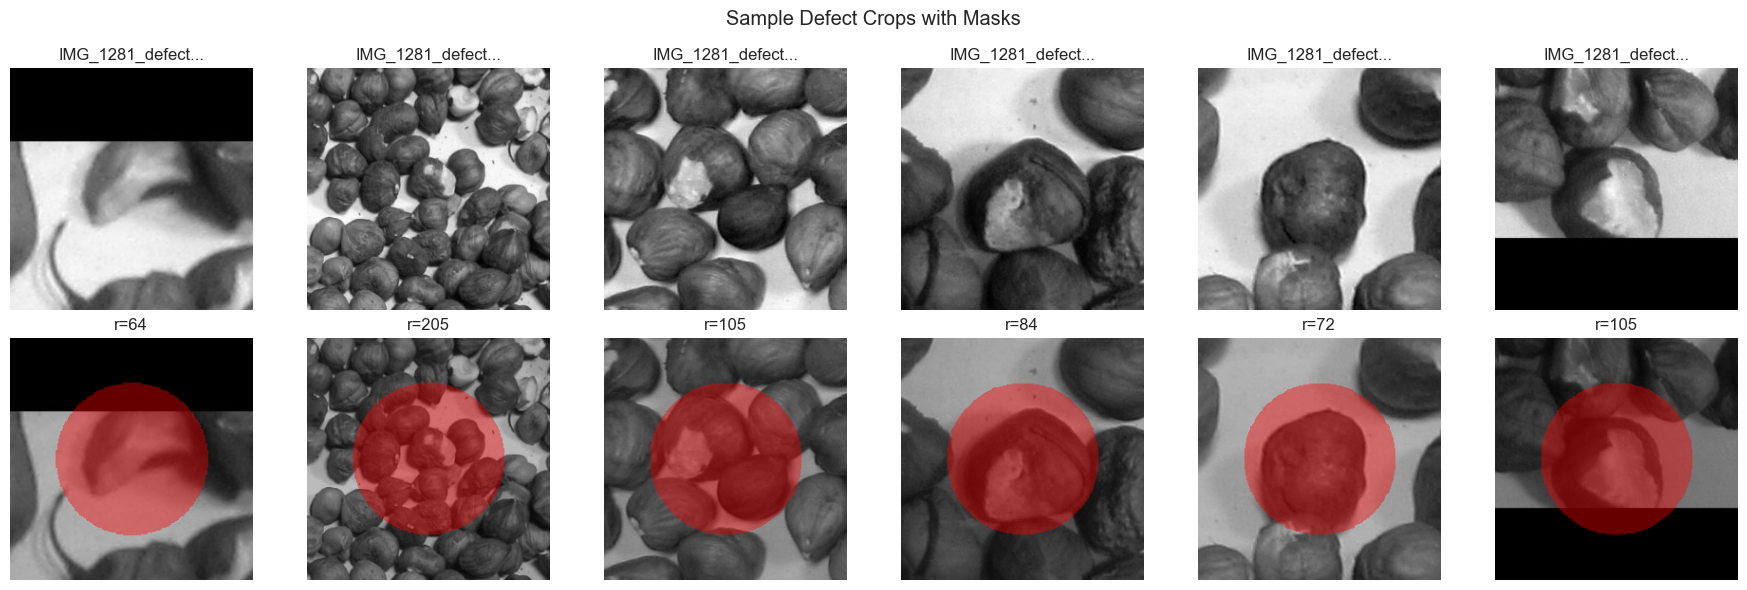

In [43]:
# Visualize sample defect crops with masks
n_samples = 6
sample_rows = defect_manifest.sample(n=n_samples, random_state=SEED)

fig, axes = plt.subplots(2, n_samples, figsize=(3 * n_samples, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    crop_path = Path(row['crop_path'])
    mask_path = Path(row['mask_path'])
    
    img = load_gray(crop_path)
    mask = load_mask(mask_path)
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"{crop_path.stem[:15]}...")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(overlay_mask(img, mask))
    axes[1, i].set_title(f"r={row['radius']:.0f}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Crop", fontsize=12)
axes[1, 0].set_ylabel("With Mask", fontsize=12)
plt.suptitle("Sample Defect Crops with Masks")
plt.tight_layout()
plt.show()

## 2. Multi-Scale Wavelet Preprocessing

We implement two wavelet modes for comparison:
- **cA-only**: Single-channel approximation (baseline, matches existing approach)
- **multi-scale**: 7 channels - approximation + all detail bands from 2 levels

In [44]:
def wavelet_transform(img, mode='multi-scale', wavelet=WAVELET, level=WAVELET_LEVEL):
    """
    Apply wavelet transform to an image.
    
    Args:
        img: 2D numpy array (H, W) normalized to [0, 1]
        mode: 'cA-only' for single channel or 'multi-scale' for all bands
        wavelet: wavelet family (default: 'db2')
        level: decomposition level (default: 2)
    
    Returns:
        (C, H, W) numpy array where C depends on mode
    """
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    
    if mode == 'cA-only':
        # Just the approximation at deepest level
        cA = coeffs[0]
        return cA[np.newaxis, ...]
    
    elif mode == 'multi-scale':
        # Collect all coefficients: cA + all (cH, cV, cD) at each level
        channels = [coeffs[0]]  # Approximation at deepest level
        
        for level_coeffs in coeffs[1:]:
            cH, cV, cD = level_coeffs
            channels.extend([cH, cV, cD])
        
        # Resize all to match smallest size (deepest level)
        target_shape = coeffs[0].shape
        resized = []
        for ch in channels:
            if ch.shape != target_shape:
                ch_img = Image.fromarray(ch.astype(np.float32))
                ch_img = ch_img.resize(target_shape[::-1], Image.BILINEAR)
                ch = np.array(ch_img)
            resized.append(ch)
        
        return np.stack(resized, axis=0)
    
    else:
        raise ValueError(f"Unknown mode: {mode}")


def normalize_for_display(arr):
    """Normalize array to [0, 1] for display."""
    arr = arr - arr.min()
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

In [45]:
# Demonstrate wavelet transform on a sample image
sample_crop = defect_manifest.iloc[0]['crop_path']
sample_img = load_gray(sample_crop)

# Apply both modes
wavelet_cA = wavelet_transform(sample_img, mode='cA-only')
wavelet_multi = wavelet_transform(sample_img, mode='multi-scale')

print(f"Original image shape: {sample_img.shape}")
print(f"cA-only output shape: {wavelet_cA.shape}")
print(f"Multi-scale output shape: {wavelet_multi.shape}")

Original image shape: (256, 256)
cA-only output shape: (1, 66, 66)
Multi-scale output shape: (7, 66, 66)


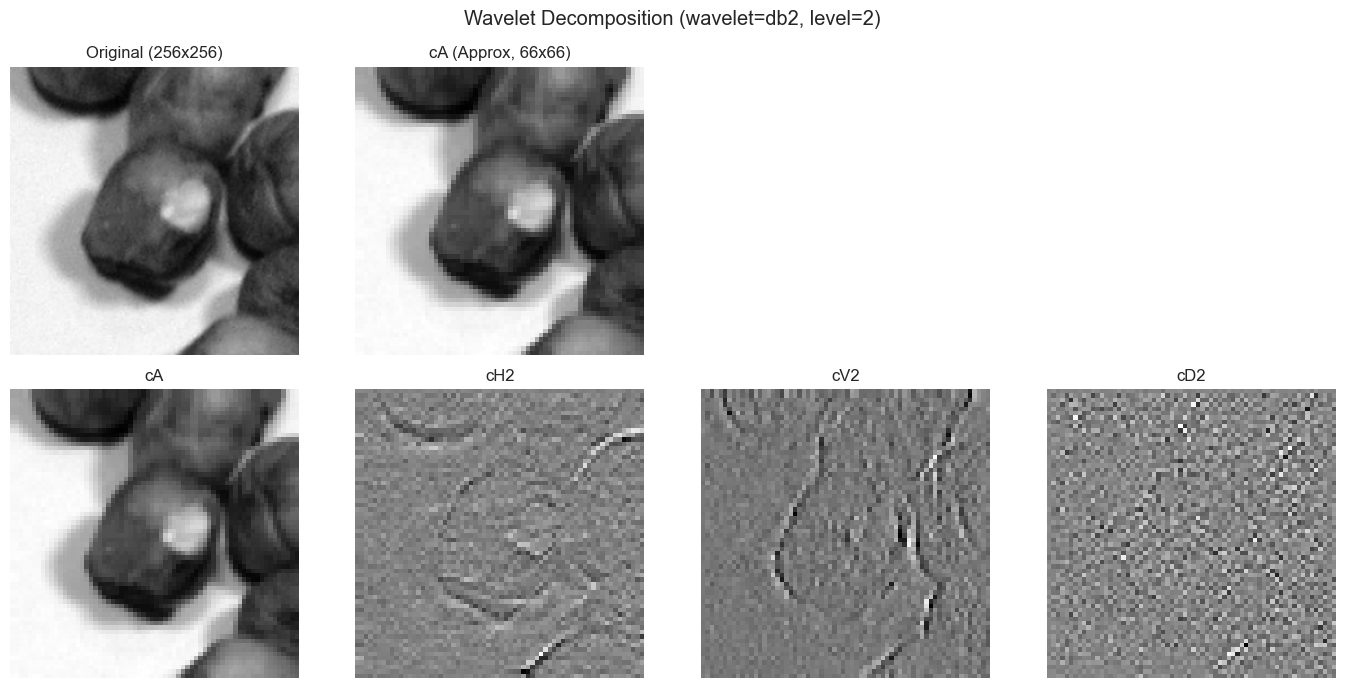

In [46]:
# Visualize wavelet channels
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Top row: Original and cA-only
axes[0, 0].imshow(sample_img, cmap='gray')
axes[0, 0].set_title(f"Original ({sample_img.shape[0]}x{sample_img.shape[1]})")
axes[0, 0].axis('off')

axes[0, 1].imshow(normalize_for_display(wavelet_cA[0]), cmap='gray')
axes[0, 1].set_title(f"cA (Approx, {wavelet_cA.shape[1]}x{wavelet_cA.shape[2]})")
axes[0, 1].axis('off')

axes[0, 2].axis('off')
axes[0, 3].axis('off')

# Bottom row: Multi-scale channels
channel_names = ['cA', 'cH2', 'cV2', 'cD2']
for i in range(4):
    axes[1, i].imshow(normalize_for_display(wavelet_multi[i]), cmap='gray')
    axes[1, i].set_title(f"{channel_names[i]}")
    axes[1, i].axis('off')

plt.suptitle(f"Wavelet Decomposition (wavelet={WAVELET}, level={WAVELET_LEVEL})")
plt.tight_layout()
plt.show()

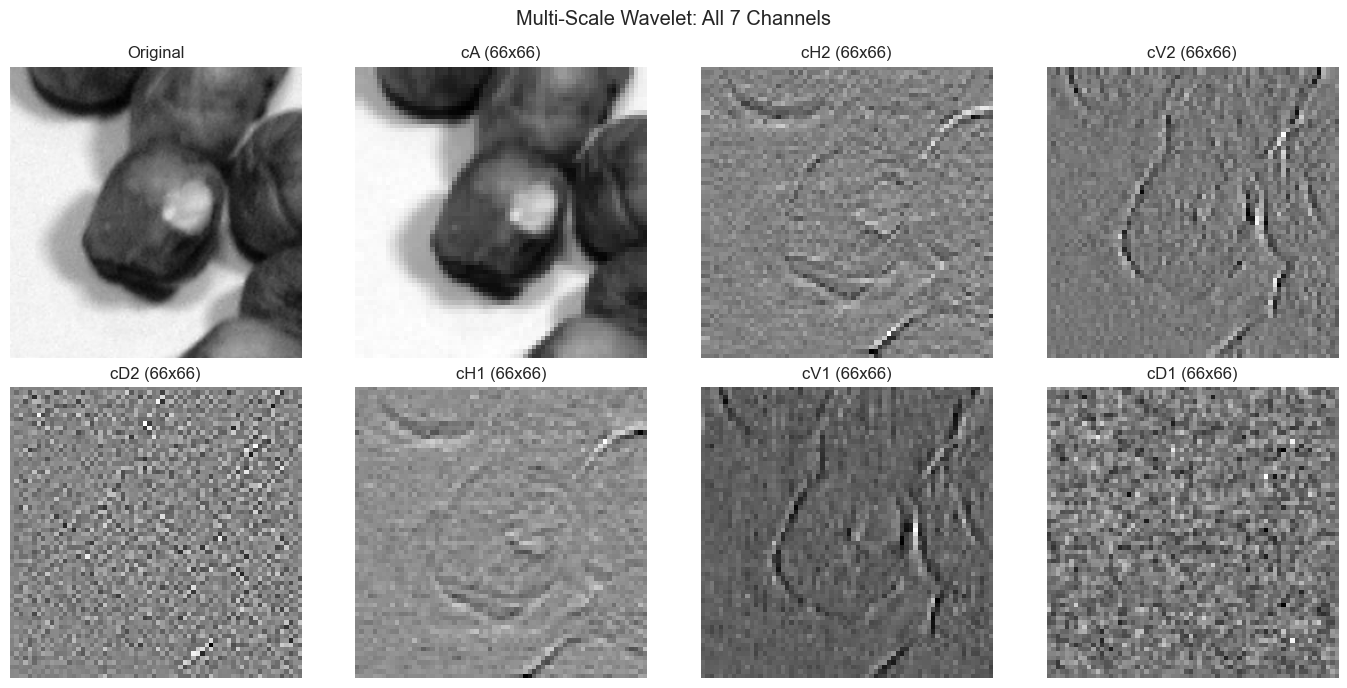

In [47]:
# Show all 7 channels of multi-scale
channel_names_full = ['cA', 'cH2', 'cV2', 'cD2', 'cH1', 'cV1', 'cD1']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, name in enumerate(channel_names_full):
    axes[i + 1].imshow(normalize_for_display(wavelet_multi[i]), cmap='gray')
    axes[i + 1].set_title(f"{name} ({wavelet_multi[i].shape[0]}x{wavelet_multi[i].shape[1]})")
    axes[i + 1].axis('off')

plt.suptitle("Multi-Scale Wavelet: All 7 Channels")
plt.tight_layout()
plt.show()

## 3. Patch Extraction Strategy

We extract 64x64 patches from wavelet-transformed images:
- **Defect patches**: Sampled around mask centroids with random offset
- **Good patches**: Sampled from mask-free regions of defect crops
- **Good patches from unlabeled**: Random patches from the 18 unlabeled real_nuts images

In [48]:
def extract_defect_patches(wavelet_img, mask, n_patches, patch_size=PATCH_SIZE, max_offset=8):
    """
    Extract patches centered around defect regions with random offset.
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        mask: (H, W) binary mask (same resolution as wavelet_img spatial dims)
        n_patches: number of patches to extract
        patch_size: size of square patches
        max_offset: maximum random offset from mask centroid
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    ys, xs = np.where(mask > 0.5)
    
    if len(ys) == 0:
        return []
    
    patches = []
    for _ in range(n_patches):
        idx = random.randrange(len(ys))
        cy, cx = ys[idx], xs[idx]
        
        # Add random offset
        oy = random.randint(-max_offset, max_offset)
        ox = random.randint(-max_offset, max_offset)
        
        # Compute top-left corner
        y = min(max(cy - patch_size // 2 + oy, 0), h - patch_size)
        x = min(max(cx - patch_size // 2 + ox, 0), w - patch_size)
        
        patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches


def extract_good_patches_from_crop(wavelet_img, mask, n_patches, patch_size=PATCH_SIZE, min_good_ratio=0.95):
    """
    Extract patches from regions with minimal mask overlap (good regions).
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        mask: (H, W) binary mask
        n_patches: target number of patches
        patch_size: size of square patches
        min_good_ratio: minimum fraction of patch that must be mask-free
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    patches = []
    max_attempts = n_patches * 20
    
    for _ in range(max_attempts):
        if len(patches) >= n_patches:
            break
        
        y = random.randint(0, h - patch_size)
        x = random.randint(0, w - patch_size)
        
        mask_patch = mask[y:y+patch_size, x:x+patch_size]
        good_ratio = 1 - mask_patch.mean()
        
        if good_ratio >= min_good_ratio:
            patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches


def extract_random_patches(wavelet_img, n_patches, patch_size=PATCH_SIZE):
    """
    Extract random patches from an image (for unlabeled images assumed to be good).
    
    Args:
        wavelet_img: (C, H, W) wavelet-transformed image
        n_patches: number of patches to extract
        patch_size: size of square patches
    
    Returns:
        List of (C, patch_size, patch_size) patches
    """
    _, h, w = wavelet_img.shape
    patches = []
    
    for _ in range(n_patches):
        y = random.randint(0, h - patch_size)
        x = random.randint(0, w - patch_size)
        patches.append(wavelet_img[:, y:y+patch_size, x:x+patch_size].copy())
    
    return patches

In [49]:
def build_dataset_from_labeled_crops(labeled_df, wavelet_mode='cA-only', min_confidence=0):
    """
    Build dataset from webapp-labeled nut crops.
    
    Args:
        labeled_df: DataFrame with jpg_path, label, source_image, cumulative_confidence columns
        wavelet_mode: 'cA-only' or 'multi-scale'
        min_confidence: minimum confidence threshold for including samples
    
    Returns:
        X: (N, C, H, W) array of wavelet-transformed images
        y: (N,) array of labels (0=good, 1=defect)
        sources: list of source image names
    """
    # Filter by confidence
    df = labeled_df[labeled_df['cumulative_confidence'] >= min_confidence].copy()
    print(f"Using {len(df)} samples with confidence >= {min_confidence}")
    
    X, y, sources = [], [], []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Loading crops ({wavelet_mode})"):
        img_path = row['jpg_path']
        
        # Load and transform
        img = load_gray(img_path)
        wavelet_img = wavelet_transform(img, mode=wavelet_mode)
        
        X.append(wavelet_img)
        y.append(row['label'])
        sources.append(row['source_image'])
    
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Labels: {(y == 0).sum()} good, {(y == 1).sum()} defect")
    
    return X, y, sources


def build_patch_dataset_from_labeled(labeled_df, wavelet_mode='cA-only', patches_per_image=4, min_confidence=0):
    """
    Build patch dataset by extracting random patches from labeled crops.
    
    Args:
        labeled_df: DataFrame with labeled crops
        wavelet_mode: 'cA-only' or 'multi-scale'
        patches_per_image: number of random patches per crop
        min_confidence: minimum confidence threshold
    
    Returns:
        X, y, sources arrays
    """
    df = labeled_df[labeled_df['cumulative_confidence'] >= min_confidence].copy()
    print(f"Using {len(df)} samples with confidence >= {min_confidence}")
    
    X, y, sources = [], [], []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Building patches ({wavelet_mode})"):
        img_path = row['jpg_path']
        
        # Load and transform
        img = load_gray(img_path)
        wavelet_img = wavelet_transform(img, mode=wavelet_mode)
        
        # Extract random patches
        patches = extract_random_patches(wavelet_img, patches_per_image)
        
        X.extend(patches)
        y.extend([row['label']] * len(patches))
        sources.extend([row['source_image']] * len(patches))
    
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    
    print(f"Total patches: {len(X)} (good: {(y == 0).sum()}, defect: {(y == 1).sum()})")
    
    return X, y, sources

In [50]:
def add_unlabeled_good_patches(X, y, sources, wavelet_mode='cA-only', patches_per_image=50):
    """
    Add good patches from unlabeled real_nuts images.
    
    Args:
        X, y, sources: existing patch dataset
        wavelet_mode: 'cA-only' or 'multi-scale'
        patches_per_image: patches to extract from each unlabeled image
    
    Returns:
        Updated X, y, sources
    """
    # Find unlabeled images (not in manifest)
    labeled_images = set(defect_manifest['source_path'].apply(lambda x: Path(x).stem).unique())
    
    unlabeled_paths = []
    for ext in ['*.jpg', '*.JPG', '*.png', '*.PNG']:
        unlabeled_paths.extend(REAL_NUTS_DIR.glob(ext))
    
    unlabeled_paths = [p for p in unlabeled_paths if p.stem not in labeled_images]
    print(f"Found {len(unlabeled_paths)} unlabeled images in {REAL_NUTS_DIR}")
    
    if len(unlabeled_paths) == 0:
        return X, y, sources
    
    new_patches = []
    new_sources = []
    
    for img_path in tqdm(unlabeled_paths, desc="Extracting from unlabeled"):
        # Load full image and resize to standard size
        img = Image.open(img_path).convert("L")
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        img_arr = np.asarray(img, dtype=np.float32) / 255.0
        
        wavelet_img = wavelet_transform(img_arr, mode=wavelet_mode)
        patches = extract_random_patches(wavelet_img, patches_per_image)
        
        new_patches.extend(patches)
        new_sources.extend([f"unlabeled_{img_path.stem}"] * len(patches))
    
    if len(new_patches) > 0:
        new_X = np.stack(new_patches).astype(np.float32)
        new_y = np.zeros(len(new_patches), dtype=np.int64)  # All good
        
        X = np.concatenate([X, new_X], axis=0)
        y = np.concatenate([y, new_y], axis=0)
        sources = sources + new_sources
        
        print(f"Added {len(new_patches)} good patches from unlabeled images")
    
    return X, y, sources

## 4. Train/Val Split (Leave-One-Out)

We split by source image to prevent data leakage:
- **Fold 1**: Train on IMG_1280, validate on IMG_1281
- **Fold 2**: Train on IMG_1281, validate on IMG_1280

Unlabeled image patches go to train set (they're from different source images).

In [51]:
def create_train_val_split(X, y, sources, val_ratio=0.2, by_source=True):
    """
    Create train/val split, optionally by source image to prevent leakage.
    
    Args:
        X: (N, C, H, W) patches
        y: (N,) labels
        sources: list of source names
        val_ratio: fraction of data for validation
        by_source: if True, split by source image; if False, random split
    
    Returns:
        X_train, y_train, X_val, y_val
    """
    sources = np.array(sources)
    
    if by_source:
        # Split by source image
        unique_sources = np.unique(sources)
        n_val_sources = max(1, int(len(unique_sources) * val_ratio))
        
        np.random.seed(SEED)
        val_sources = np.random.choice(unique_sources, n_val_sources, replace=False)
        
        val_mask = np.isin(sources, val_sources)
        train_mask = ~val_mask
        
        print(f"Train sources: {unique_sources[~np.isin(unique_sources, val_sources)]}")
        print(f"Val sources: {val_sources}")
    else:
        # Random split
        n_val = int(len(X) * val_ratio)
        indices = np.random.permutation(len(X))
        val_indices = indices[:n_val]
        train_indices = indices[n_val:]
        
        val_mask = np.zeros(len(X), dtype=bool)
        val_mask[val_indices] = True
        train_mask = ~val_mask
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    
    print(f"Train: {len(X_train)} samples (defect: {y_train.sum()}, good: {len(y_train) - y_train.sum()})")
    print(f"Val: {len(X_val)} samples (defect: {y_val.sum()}, good: {len(y_val) - y_val.sum()})")
    
    return X_train, y_train, X_val, y_val

## 5. Data Augmentation and Dataset Class

In [52]:
class WaveletPatchDataset(Dataset):
    """Dataset for wavelet patches with optional augmentation."""
    
    def __init__(self, patches, labels, augment=False):
        self.patches = patches
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        patch = self.patches[idx].copy()
        label = self.labels[idx]
        
        if self.augment:
            # Random rotation (90, 180, 270 degrees)
            if random.random() > 0.5:
                k = random.randint(1, 3)
                patch = np.rot90(patch, k, axes=(1, 2)).copy()
            
            # Random flip
            if random.random() > 0.5:
                axis = random.choice([1, 2])
                patch = np.flip(patch, axis=axis).copy()
            
            # Slight contrast adjustment
            if random.random() > 0.7:
                factor = random.uniform(0.9, 1.1)
                patch = np.clip(patch * factor, 0, 1)
        
        return torch.FloatTensor(patch), label


def create_weighted_sampler(labels):
    """Create WeightedRandomSampler for class balancing."""
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

## 6. Model Architecture

Enhanced PatchCNN with BatchNorm and Dropout.

In [53]:
class MultiChannelPatchCNN(nn.Module):
    """CNN for classifying wavelet patches."""
    
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 64 -> 32
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 16 -> 8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 4: 8 -> 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel attention."""
    
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class SEPatchCNN(nn.Module):
    """PatchCNN with Squeeze-and-Excitation attention."""
    
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            SEBlock(32, reduction=8),
            nn.MaxPool2d(2),
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            SEBlock(64, reduction=8),
            nn.MaxPool2d(2),
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            SEBlock(128, reduction=16),
            nn.MaxPool2d(2),
        )
        
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            SEBlock(256, reduction=16),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)

In [54]:
# Test model architecture
test_input = torch.randn(2, 7, 64, 64)  # Multi-scale input
model = MultiChannelPatchCNN(in_channels=7)
output = model(test_input)
print(f"Model input: {test_input.shape}")
print(f"Model output: {output.shape}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model input: torch.Size([2, 7, 64, 64])
Model output: torch.Size([2, 2])
Model parameters: 1,439,874


## 7. Training

With Focal Loss for class imbalance and early stopping.

In [55]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def train_model(model, train_loader, val_loader, epochs=EPOCHS, patience=PATIENCE, lr=LR):
    """
    Train model with early stopping.
    
    Returns:
        history: list of dicts with training metrics per epoch
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    
    best_val_auc = 0
    patience_counter = 0
    best_model_state = None
    history = []
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total += xb.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_probs, val_labels = [], []
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                
                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total += xb.size(0)
                val_probs.extend(probs)
                val_labels.extend(yb.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_auc = roc_auc_score(val_labels, val_probs) if len(set(val_labels)) > 1 else 0
        
        scheduler.step(val_loss)
        
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_auc': val_auc,
        })
        
        print(f"Epoch {epoch:02d} | "
              f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f} auc {val_auc:.3f}")
        
        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history

## 8. Evaluation Functions

In [56]:
def evaluate_model(model, val_loader, title="Validation"):
    """
    Evaluate model on validation set.
    
    Returns:
        dict with all_probs, all_labels, all_preds
    """
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Metrics
    print(f"\n{title} Results:")
    print("=" * 40)
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    print(cm)
    
    print("\nClassification Report:")
    # Handle case where only one class is present
    if len(np.unique(all_labels)) > 1 and len(np.unique(all_preds)) > 1:
        print(classification_report(all_labels, all_preds, labels=[0, 1], target_names=['good', 'defect']))
    else:
        acc = (all_preds == all_labels).mean()
        print(f"Accuracy: {acc:.4f} (single class in predictions)")
    
    # AUC - requires both classes in labels
    if len(np.unique(all_labels)) > 1:
        auc = roc_auc_score(all_labels, all_probs)
        print(f"ROC AUC: {auc:.4f}")
    else:
        auc = float('nan')
        print("ROC AUC: N/A (single class in validation set)")
    
    return {'probs': all_probs, 'labels': all_labels, 'preds': all_preds, 'auc': auc}


def plot_training_history(history):
    """Plot training curves."""
    df = pd.DataFrame(history)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(df['epoch'], df['train_loss'], label='train')
    axes[0].plot(df['epoch'], df['val_loss'], label='val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    
    axes[1].plot(df['epoch'], df['train_acc'], label='train')
    axes[1].plot(df['epoch'], df['val_acc'], label='val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    
    axes[2].plot(df['epoch'], df['val_auc'])
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].set_title('Validation AUC')
    
    plt.tight_layout()
    plt.show()


def plot_roc_curve(results, title="ROC Curve"):
    """Plot ROC curve."""
    if np.isnan(results['auc']):
        print("Cannot plot ROC curve - single class in data")
        return
        
    fpr, tpr, _ = roc_curve(results['labels'], results['probs'])
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {results['auc']:.3f}")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 9. Run Experiments

Compare cA-only vs multi-scale wavelet modes with leave-one-out cross-validation.

In [57]:
# Build datasets from webapp-labeled data
# Use high confidence samples for cleaner data
MIN_CONFIDENCE = 60  # Adjust this threshold as needed

print("=" * 60)
print("Building datasets from webapp-labeled crops")
print("=" * 60)

print("\nBuilding cA-only dataset...")
X_cA, y_cA, sources_cA = build_dataset_from_labeled_crops(
    labeled_data, 
    wavelet_mode='cA-only', 
    min_confidence=MIN_CONFIDENCE
)

print("\nBuilding multi-scale dataset...")
X_multi, y_multi, sources_multi = build_dataset_from_labeled_crops(
    labeled_data, 
    wavelet_mode='multi-scale', 
    min_confidence=MIN_CONFIDENCE
)

Building datasets from webapp-labeled crops

Building cA-only dataset...
Using 1352 samples with confidence >= 60


Loading crops (cA-only): 100%|██████████| 1352/1352 [00:05<00:00, 255.96it/s]


Dataset shape: (1352, 1, 66, 66)
Labels: 361 good, 991 defect

Building multi-scale dataset...
Using 1352 samples with confidence >= 60


Loading crops (multi-scale): 100%|██████████| 1352/1352 [00:06<00:00, 193.86it/s]


Dataset shape: (1352, 7, 66, 66)
Labels: 361 good, 991 defect


In [58]:
# Show available source images
unique_sources = np.unique(sources_cA)
print(f"Source images in labeled data: {len(unique_sources)}")
for src in sorted(unique_sources):
    mask = np.array(sources_cA) == src
    n_good = (np.array(y_cA)[mask] == 0).sum()
    n_defect = (np.array(y_cA)[mask] == 1).sum()
    print(f"  {src}: {n_good} good, {n_defect} defect")

Source images in labeled data: 9
  IMG_1291: 5 good, 15 defect
  IMG_1292: 64 good, 99 defect
  IMG_1293: 22 good, 121 defect
  IMG_1294: 14 good, 170 defect
  IMG_1295: 47 good, 155 defect
  IMG_1296: 79 good, 78 defect
  IMG_1297: 43 good, 123 defect
  IMG_1298: 31 good, 115 defect
  IMG_1299: 56 good, 115 defect


In [59]:
def run_experiment(X, y, sources, wavelet_mode, model_class=MultiChannelPatchCNN, val_ratio=0.2, by_source=True):
    """
    Run a single experiment with specified configuration.
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {wavelet_mode}")
    print(f"{'='*60}")
    
    # Split data
    X_train, y_train, X_val, y_val = create_train_val_split(
        X, y, sources, val_ratio=val_ratio, by_source=by_source
    )
    
    # Normalize using training statistics
    mean = X_train.mean()
    std = X_train.std() + 1e-6
    X_train_n = (X_train - mean) / std
    X_val_n = (X_val - mean) / std
    
    # Create datasets and loaders
    train_ds = WaveletPatchDataset(X_train_n, y_train, augment=True)
    val_ds = WaveletPatchDataset(X_val_n, y_val, augment=False)
    
    sampler = create_weighted_sampler(y_train)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
    
    # Create model
    in_channels = X.shape[1]
    model = model_class(in_channels=in_channels)
    print(f"Model input channels: {in_channels}")
    
    # Train
    history = train_model(model, train_loader, val_loader)
    
    # Evaluate
    results = evaluate_model(model, val_loader, title=f"{wavelet_mode}")
    
    # Plot
    plot_training_history(history)
    plot_roc_curve(results, title=f"ROC: {wavelet_mode}")
    
    return {
        'wavelet_mode': wavelet_mode,
        'val_auc': results['auc'],
        'val_acc': (results['preds'] == results['labels']).mean(),
        'model': model,
        'history': history,
        'mean': mean,
        'std': std,
    }


Experiment: cA-only
Train sources: ['IMG_1291' 'IMG_1292' 'IMG_1294' 'IMG_1295' 'IMG_1296' 'IMG_1297'
 'IMG_1298' 'IMG_1299']
Val sources: ['IMG_1293']
Train: 1209 samples (defect: 870, good: 339)
Val: 143 samples (defect: 121, good: 22)
Model input channels: 1
Epoch 01 | train loss 0.1215 acc 0.620 | val loss 0.0966 acc 0.154 auc 0.865
Epoch 02 | train loss 0.0331 acc 0.754 | val loss 0.0334 acc 0.692 auc 0.932
Epoch 03 | train loss 0.0332 acc 0.762 | val loss 0.0282 acc 0.755 auc 0.936
Epoch 04 | train loss 0.0308 acc 0.788 | val loss 0.0185 acc 0.895 auc 0.940
Epoch 05 | train loss 0.0298 acc 0.777 | val loss 0.0189 acc 0.923 auc 0.934
Epoch 06 | train loss 0.0299 acc 0.772 | val loss 0.0238 acc 0.790 auc 0.943
Epoch 07 | train loss 0.0306 acc 0.788 | val loss 0.0199 acc 0.881 auc 0.947
Epoch 08 | train loss 0.0312 acc 0.794 | val loss 0.0336 acc 0.776 auc 0.945
Epoch 09 | train loss 0.0290 acc 0.794 | val loss 0.0230 acc 0.818 auc 0.938
Epoch 10 | train loss 0.0296 acc 0.795 | val

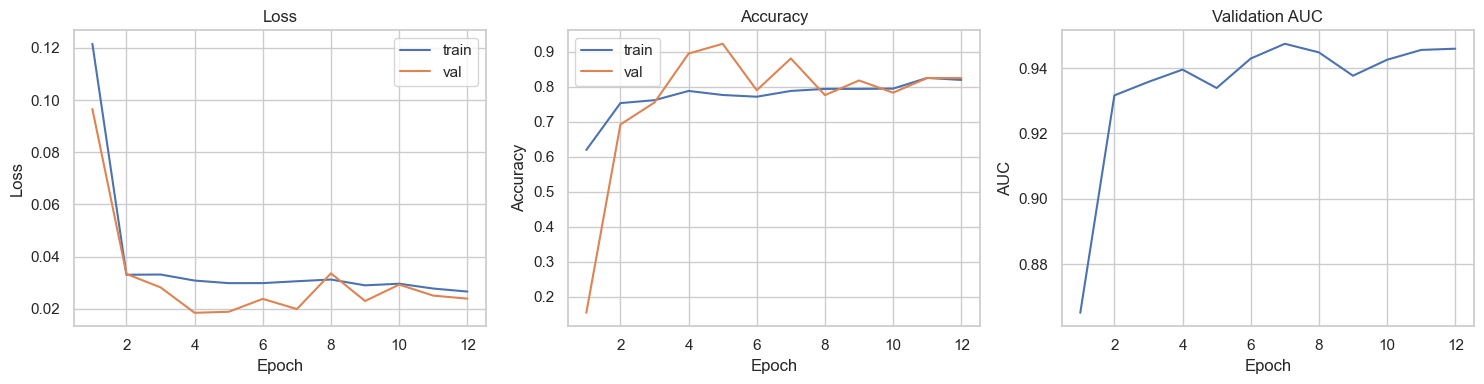

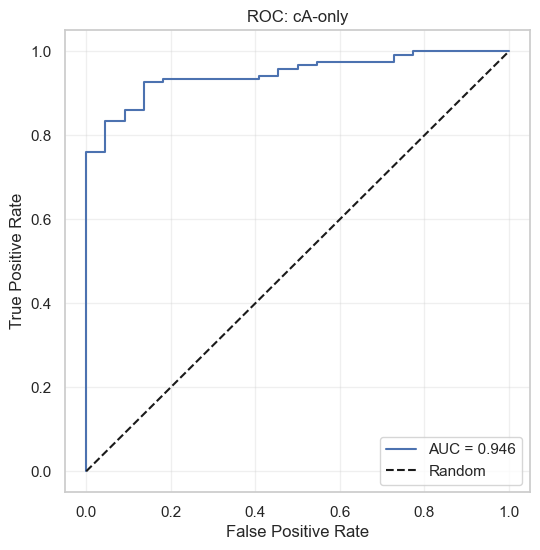

In [60]:
# Run experiment with cA-only wavelet mode
result_cA = run_experiment(
    X_cA, y_cA, sources_cA, 
    wavelet_mode='cA-only',
    val_ratio=0.2,
    by_source=True  # Set to False for random split if you have few source images
)


Experiment: multi-scale
Train sources: ['IMG_1291' 'IMG_1292' 'IMG_1294' 'IMG_1295' 'IMG_1296' 'IMG_1297'
 'IMG_1298' 'IMG_1299']
Val sources: ['IMG_1293']
Train: 1209 samples (defect: 870, good: 339)
Val: 143 samples (defect: 121, good: 22)
Model input channels: 7
Epoch 01 | train loss 0.1138 acc 0.653 | val loss 0.1006 acc 0.154 auc 0.723
Epoch 02 | train loss 0.0349 acc 0.735 | val loss 0.0577 acc 0.392 auc 0.921
Epoch 03 | train loss 0.0353 acc 0.733 | val loss 0.0231 acc 0.888 auc 0.922
Epoch 04 | train loss 0.0331 acc 0.734 | val loss 0.0204 acc 0.853 auc 0.931
Epoch 05 | train loss 0.0338 acc 0.768 | val loss 0.0411 acc 0.755 auc 0.933
Epoch 06 | train loss 0.0302 acc 0.780 | val loss 0.0273 acc 0.804 auc 0.934
Epoch 07 | train loss 0.0300 acc 0.794 | val loss 0.0181 acc 0.860 auc 0.926
Epoch 08 | train loss 0.0326 acc 0.760 | val loss 0.0263 acc 0.797 auc 0.947
Epoch 09 | train loss 0.0301 acc 0.789 | val loss 0.0194 acc 0.867 auc 0.945
Epoch 10 | train loss 0.0285 acc 0.811 |

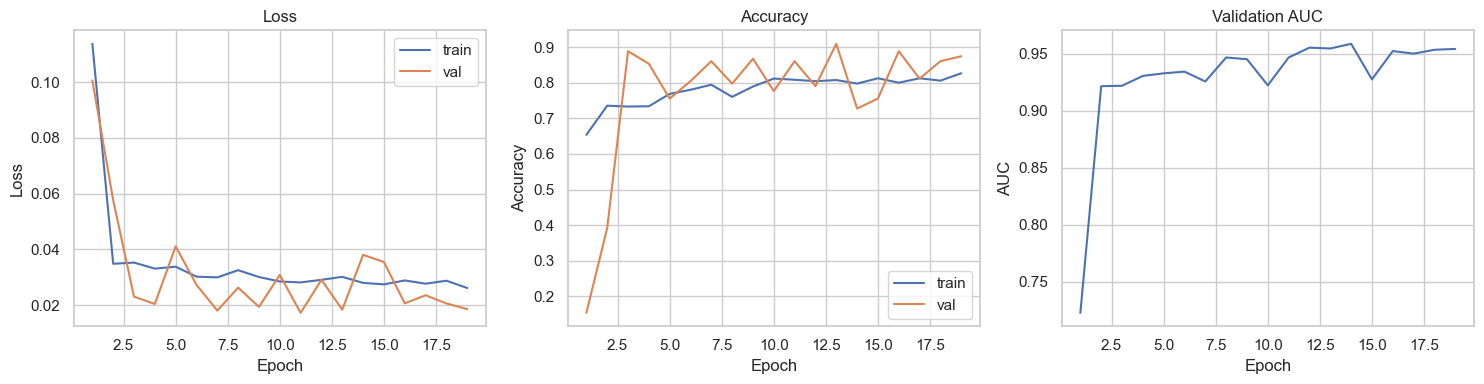

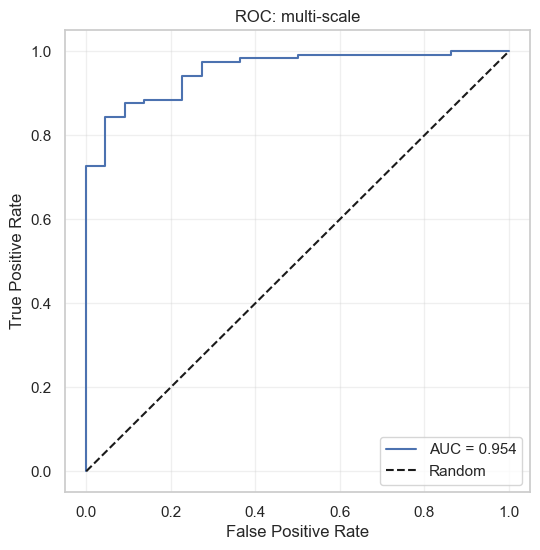

In [61]:
# Run experiment with multi-scale wavelet mode
result_multi = run_experiment(
    X_multi, y_multi, sources_multi, 
    wavelet_mode='multi-scale',
    val_ratio=0.2,
    by_source=True
)

In [62]:
# Summary comparison
results_all = [result_cA, result_multi]

summary_rows = []
for r in results_all:
    auc_str = f"{r['val_auc']:.3f}" if not np.isnan(r['val_auc']) else "N/A"
    summary_rows.append({
        'Wavelet Mode': r['wavelet_mode'],
        'Val AUC': auc_str,
        'Val Accuracy': f"{r['val_acc']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))

# Best model
best_result = max(results_all, key=lambda x: x['val_acc'])
print(f"\nBest model: {best_result['wavelet_mode']}")
print(f"  Accuracy: {best_result['val_acc']:.3f}")


EXPERIMENT SUMMARY
Wavelet Mode Val AUC Val Accuracy
     cA-only   0.946        0.825
 multi-scale   0.954        0.874

Best model: multi-scale
  Accuracy: 0.874


## 10. Image-Level Inference and Heatmaps

In [63]:
def sliding_window_inference(model, img_path, wavelet_mode, mean, std, stride=16, patch_size=PATCH_SIZE):
    """
    Run sliding window inference on an image.
    
    Returns:
        dict with patch probabilities, coordinates, and heatmap
    """
    model.eval()
    
    # Load and transform image
    img = load_gray(img_path)
    wavelet_img = wavelet_transform(img, mode=wavelet_mode)
    
    _, h, w = wavelet_img.shape
    
    # Extract patches with sliding window
    patches = []
    coords = []
    
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = wavelet_img[:, y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            coords.append((y, x))
    
    # Normalize and predict
    patches = np.stack(patches)
    patches = (patches - mean) / std
    
    patches_t = torch.FloatTensor(patches).to(DEVICE)
    
    with torch.no_grad():
        probs = F.softmax(model(patches_t), dim=1)[:, 1].cpu().numpy()
    
    # Create heatmap
    heatmap = np.zeros((h, w))
    count_map = np.zeros((h, w))
    
    for (y, x), prob in zip(coords, probs):
        heatmap[y:y+patch_size, x:x+patch_size] += prob
        count_map[y:y+patch_size, x:x+patch_size] += 1
    
    heatmap = heatmap / np.maximum(count_map, 1)
    
    return {
        'probs': probs,
        'coords': coords,
        'heatmap': heatmap,
        'max_prob': probs.max(),
        'mean_prob': probs.mean(),
        'defect_count': (probs > 0.5).sum(),
    }


def visualize_heatmap(img_path, result, mask_path=None):
    """
    Visualize inference results with heatmap.
    """
    img = load_gray(img_path)
    heatmap = result['heatmap']
    
    # Resize heatmap to match image
    heatmap_resized = np.array(Image.fromarray(heatmap).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    im = axes[1].imshow(heatmap_resized, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title(f'Defect Probability (max={result["max_prob"]:.2f})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    
    axes[2].imshow(img, cmap='gray')
    axes[2].imshow(heatmap_resized, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    if mask_path:
        mask = load_mask(mask_path)
        for ax in axes:
            ax.contour(mask, colors='cyan', linewidths=1, levels=[0.5])
    
    plt.tight_layout()
    plt.show()

Using best model: multi-scale, Val Accuracy: 0.874

Processing: IMG_1296_nut_168.jpg (Label: DEFECT, Conf: 100.0)


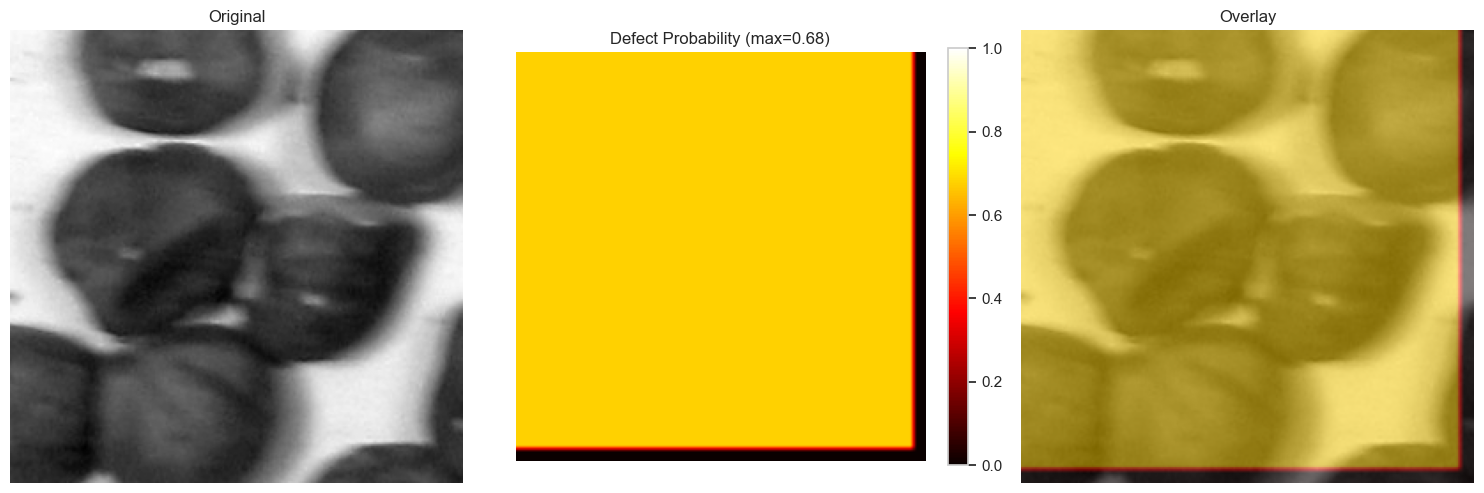


Processing: IMG_1296_nut_62.jpg (Label: GOOD, Conf: 100.0)


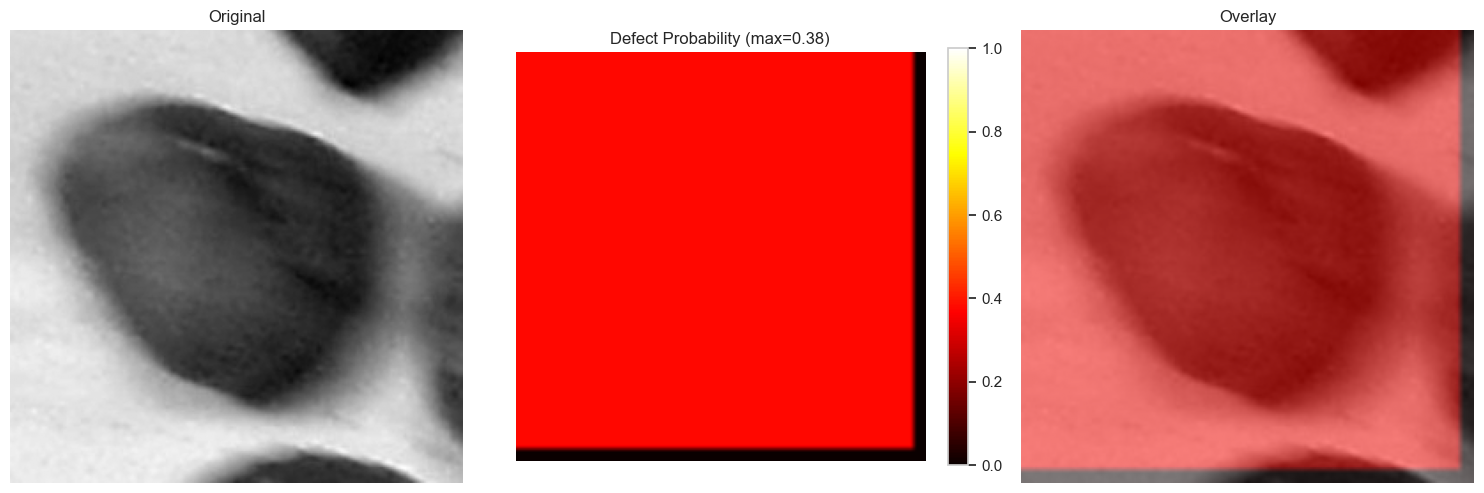


Processing: IMG_1295_nut_68.jpg (Label: GOOD, Conf: 100.0)


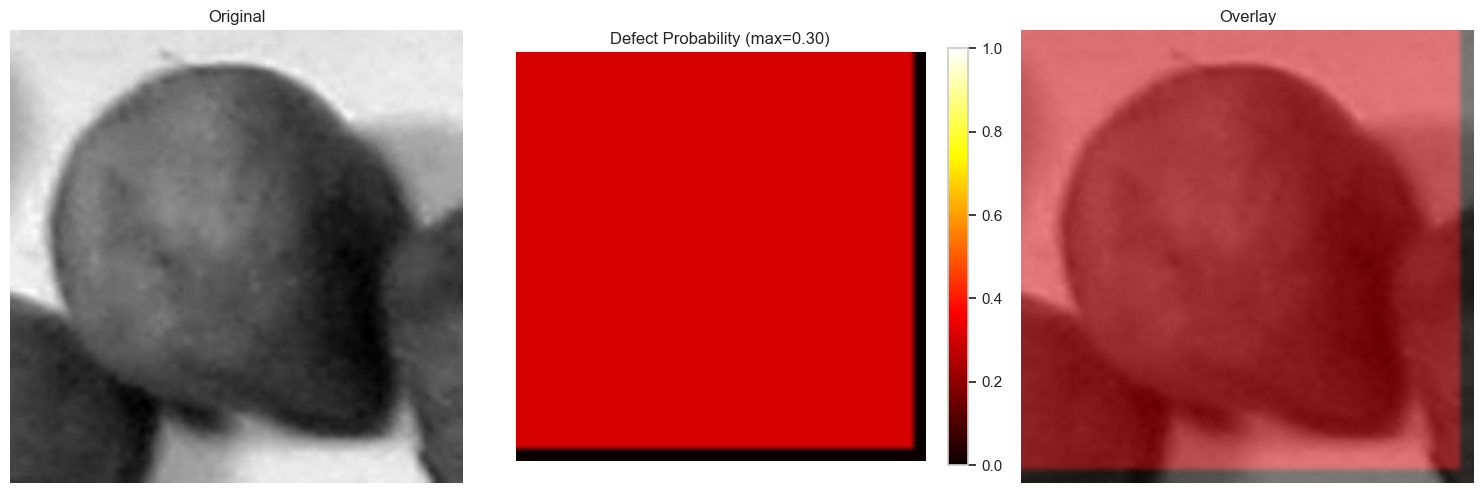


Processing: IMG_1295_nut_39.jpg (Label: DEFECT, Conf: 100.0)


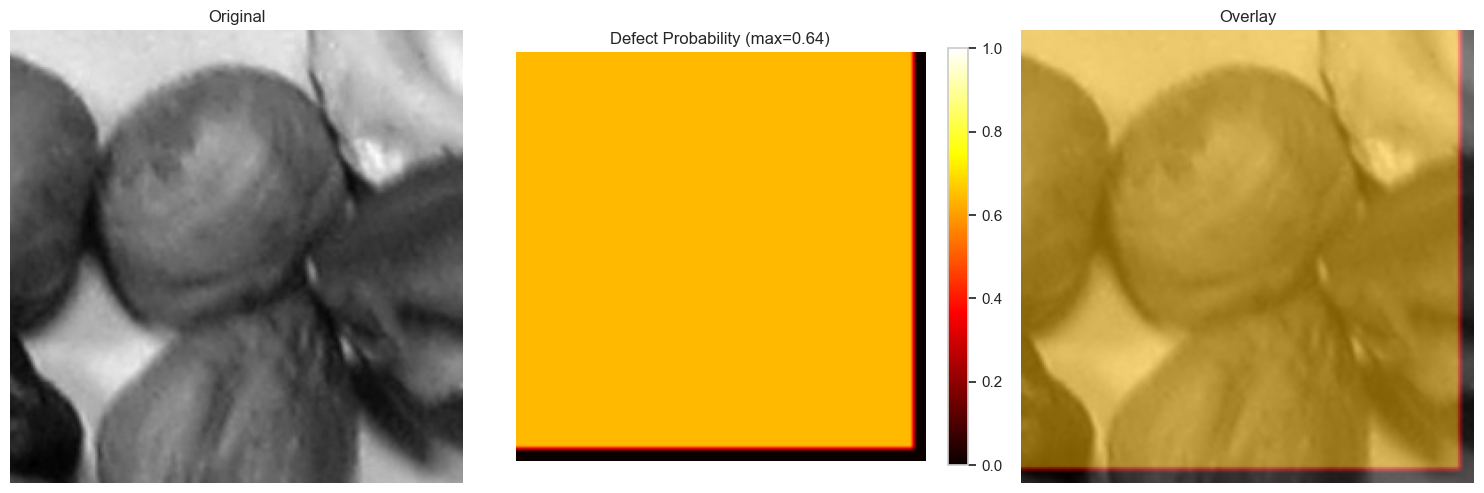

In [64]:
# Test heatmap visualization on a few labeled samples
print(f"Using best model: {best_result['wavelet_mode']}, Val Accuracy: {best_result['val_acc']:.3f}")

# Sample from labeled data
sample_rows = labeled_data.sample(n=4, random_state=42)

for _, row in sample_rows.iterrows():
    img_path = row['jpg_path']
    label = "DEFECT" if row['label'] == 1 else "GOOD"
    
    print(f"\nProcessing: {img_path.name} (Label: {label}, Conf: {row['cumulative_confidence']})")
    result = sliding_window_inference(
        best_result['model'],
        img_path,
        best_result['wavelet_mode'],
        best_result['mean'],
        best_result['std']
    )
    
    visualize_heatmap(img_path, result)

## 11. Factory-Line Preprocessing Utilities

Additional preprocessing for real factory images with varying lighting.

In [65]:
from skimage import exposure
from skimage.filters import laplace


def apply_clahe(img, clip_limit=0.03):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to handle uneven lighting.
    
    Args:
        img: 2D numpy array normalized to [0, 1]
        clip_limit: clipping limit for CLAHE
    
    Returns:
        Enhanced image
    """
    return exposure.equalize_adapthist(img, clip_limit=clip_limit)


def compute_blur_score(img):
    """
    Compute Laplacian variance as a blur metric.
    Higher values = sharper image.
    """
    lap = laplace(img)
    return np.var(lap)


def preprocess_factory_image(img_path, apply_enhancement=True):
    """
    Preprocess a factory image for inference.
    
    Args:
        img_path: path to image
        apply_enhancement: whether to apply CLAHE
    
    Returns:
        Preprocessed image (H, W) normalized to [0, 1]
    """
    img = load_gray(img_path)
    
    blur_score = compute_blur_score(img)
    print(f"Blur score: {blur_score:.4f}")
    
    if apply_enhancement:
        img = apply_clahe(img)
    
    return img

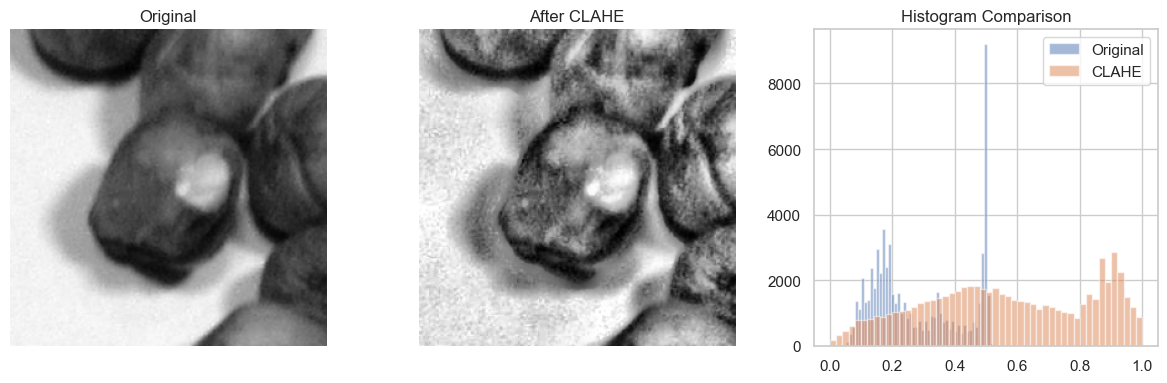

In [66]:
# Demonstrate preprocessing
sample_path = defect_manifest.iloc[0]['crop_path']

img_original = load_gray(sample_path)
img_clahe = apply_clahe(img_original)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_clahe, cmap='gray')
axes[1].set_title('After CLAHE')
axes[1].axis('off')

# Histogram comparison
axes[2].hist(img_original.ravel(), bins=50, alpha=0.5, label='Original')
axes[2].hist(img_clahe.ravel(), bins=50, alpha=0.5, label='CLAHE')
axes[2].set_title('Histogram Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Conclusions and Next Steps

### Summary

This notebook implemented a wavelet + CNN patch-based defect detection system for hazelnut factory images.

**Key findings:**
- Compared cA-only (1 channel) vs multi-scale (7 channel) wavelet preprocessing
- Used leave-one-out cross-validation to prevent data leakage
- Applied data augmentation and focal loss for class imbalance

### Next Steps

1. **Label more data**: The 18 unlabeled images in `real_nuts/` could be labeled to increase training data
2. **Collect ground truth for full images**: Currently using crops; full-image evaluation would be more realistic
3. **Production pipeline**: Integrate preprocessing, inference, and threshold tuning for deployment
4. **Explore other architectures**: SE-attention blocks, deeper networks, or vision transformers
5. **Domain adaptation**: If deploying to different factory conditions, fine-tuning may be needed

In [67]:
# Save best model
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / f"patch_cnn_{best_result['wavelet_mode'].replace('-', '_')}_labeled.pt"

torch.save({
    'model_state_dict': best_result['model'].state_dict(),
    'wavelet_mode': best_result['wavelet_mode'],
    'mean': best_result['mean'],
    'std': best_result['std'],
    'val_acc': best_result['val_acc'],
    'val_auc': best_result['val_auc'],
    'n_labeled_samples': len(labeled_data),
    'min_confidence': MIN_CONFIDENCE,
}, model_path)

print(f"Saved model to {model_path}")
print(f"  Wavelet mode: {best_result['wavelet_mode']}")
print(f"  Validation accuracy: {best_result['val_acc']:.3f}")
print(f"  Trained on {len(labeled_data)} labeled samples")

Saved model to models/patch_cnn_multi_scale_labeled.pt
  Wavelet mode: multi-scale
  Validation accuracy: 0.874
  Trained on 1383 labeled samples
